In [ ]:
import clip
import torch
from PIL import Image
import gym
import numpy as np
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

In [ ]:
def load_clip_model(device='cpu'):
    clip_model, preprocess = clip.load("ViT-B/16", device=device)
    return clip_model, preprocess


def compute_embeddings(clip_model, preprocess, inputs, device='cpu'):
    with torch.no_grad():
        if isinstance(inputs, list): 
            embeddings = clip_model.encode_text(clip.tokenize(inputs).to(device))
        else: 
            if isinstance(inputs, np.ndarray): 
                inputs = Image.fromarray((inputs * 255).astype(np.uint8))
            img = preprocess(inputs).unsqueeze(0).to(device)
            embeddings = clip_model.encode_image(img)
    return embeddings


def compute_cosine_reward(state, task_description, clip_model, preprocess, device='cpu'):
    img = Image.fromarray((state * 255).astype(np.uint8))  # Convert state to image
    image_features = compute_embeddings(clip_model, preprocess, img, device=device)
    text_features = compute_embeddings(clip_model, preprocess, [task_description], device=device)
    reward = torch.cosine_similarity(image_features, text_features).item()
    return reward




In [ ]:

def query_vlm_for_preference(clip_model, preprocess, state1, state2, task_description, device='cpu'):
    img1 = Image.fromarray((state1 * 255).astype(np.uint8))
    img2 = Image.fromarray((state2 * 255).astype(np.uint8))
    
    embedding1 = compute_embeddings(clip_model, preprocess, img1, device=device)
    embedding2 = compute_embeddings(clip_model, preprocess, img2, device=device)
    task_embedding = compute_embeddings(clip_model, preprocess, [task_description], device=device)

    sim1 = torch.cosine_similarity(embedding1, task_embedding).item()
    sim2 = torch.cosine_similarity(embedding2, task_embedding).item()

    return 1 if sim1 > sim2 else 0  



class RewardModel:
    def __init__(self):
        self.model = LogisticRegression()

    def train(self, features, labels):
        self.model.fit(features, labels)

    def predict(self, features):
        return self.model.predict_proba(features)[:, 1]  


class ClipRewardEnv(gym.Env):
    def __init__(self, env, task_description, clip_model, preprocess, preference_buffer, reward_model=None, device='cpu'):
        super(ClipRewardEnv, self).__init__()
        self.env = env
        self.task_description = task_description
        self.clip_model = clip_model
        self.preprocess = preprocess
        self.device = device
        self.preference_buffer = preference_buffer
        self.reward_model = reward_model 
        self.observation_space = self.env.observation_space
        self.action_space = self.env.action_space

    def reset(self):
        state, _ = self.env.reset()
        return np.array(state, dtype=np.float32)

    def step(self, action):
        state, _, terminated, truncated, info = self.env.step(action)

       
        if self.reward_model is not None and len(self.preference_buffer) > 100:  
            embedding = compute_embeddings(self.clip_model, self.preprocess, state, device=self.device).cpu().numpy()
            reward = self.reward_model.predict(embedding.reshape(1, -1))[0]
        else:
            
            reward = compute_cosine_reward(state, self.task_description, self.clip_model, self.preprocess, device=self.device)

        
        if np.random.rand() < 0.1:  
            state2 = self.env.observation_space.sample()  
            preference = query_vlm_for_preference(self.clip_model, self.preprocess, state, state2, self.task_description, self.device)
            self.preference_buffer.append((state, state2, preference))

        done = terminated or truncated
        return np.array(state, dtype=np.float32), reward, done, info



    

# Training part
def train_reward_model(reward_model, preference_buffer, clip_model, preprocess, device='cpu'):
    features = []
    labels = []

    for state1, state2, preference in preference_buffer:
     
        embedding1 = compute_embeddings(clip_model, preprocess, state1, device=device).cpu().numpy().flatten()
        embedding2 = compute_embeddings(clip_model, preprocess, state2, device=device).cpu().numpy().flatten()
        
       
        feature = embedding1 - embedding2
        features.append(feature)
        labels.append(preference)


    features = np.array(features)  
    labels = np.array(labels)      

   
    reward_model.train(features, labels)




In [ ]:

def main():
    global vec_env, model  
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    clip_model, preprocess = load_clip_model(device)

 
    task_description = "a car near the flag at the top of the mountain."

    env = gym.make("MountainCar-v0")
    preference_buffer = []

    clip_reward_env = ClipRewardEnv(env, task_description, clip_model, preprocess, preference_buffer, device=device)
    vec_env = DummyVecEnv([lambda: clip_reward_env])

    model = DQN(
        "MlpPolicy",
        vec_env,
        buffer_size=50000,
        batch_size=64,
        learning_rate=2.3e-3,
        train_freq=(200, "step"),
        gradient_steps=200,
        gamma=0.99,
        exploration_fraction=0.95,
        exploration_final_eps=0.1,
        target_update_interval=500,
        verbose=1,
        policy_kwargs={"net_arch": [256, 256]})

    total_timesteps = 15000
    timesteps_completed = 0  
    reward_model = RewardModel()

    while timesteps_completed < total_timesteps:
        model.learn(total_timesteps=200, reset_num_timesteps=False)
        timesteps_completed += 200  
        if len(preference_buffer) > 100:
            train_reward_model(reward_model, preference_buffer, clip_model, preprocess, device=device)

    print(f"Training complete! Total timesteps completed: {timesteps_completed}")



# Final

if __name__ == "__main__":
    main()

In [ ]:
# Save trained model
model.save("mountaincar_dqn_pref_1")
print("Model saved successfully!")

Model saved successfully!


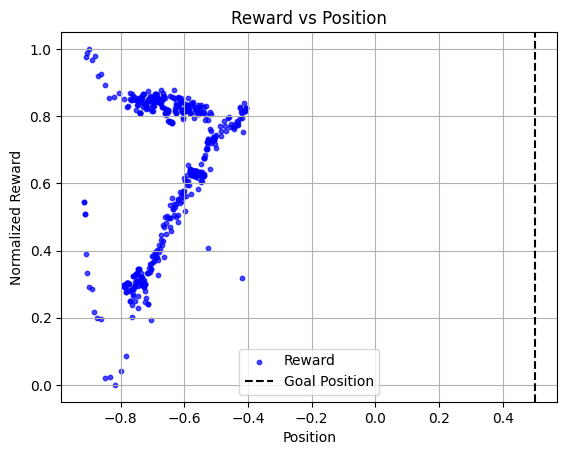

In [ ]:
positions = []
velocities = []
rewards = []


obs = vec_env.reset()  
for _ in range(500):  
    action, _ = model.predict(obs)  
    obs, reward, done, info = vec_env.step(action)

    
    position = float(obs[0][0])  
    velocity = float(obs[0][1])  
    positions.append(position)
    velocities.append(velocity)


    rewards.append(float(reward[0]))  

    if done[0]:  
        obs = vec_env.reset()


positions = np.array(positions)
velocities = np.array(velocities)
rewards = np.array(rewards)


normalized_rewards = (rewards - rewards.min()) / (rewards.max() - rewards.min())


plt.scatter(positions, normalized_rewards, s=10, alpha=0.7, color='blue', label='Reward')
plt.axvline(x=0.5, color='black', linestyle='--', label='Goal Position')
plt.xlabel("Position")
plt.ylabel("Normalized Reward")
plt.title("Reward vs Position")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Save trained model
model.save("mountaincar_dqn_pref")
print("Model saved successfully!")